In [241]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [242]:

np.random.seed(42)

pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## Part 1 - Data Cleaning & Preprocessing

Real Datasets are almost necver clean. Before training any ML model we need to handle things like:

- Nissing Values (MV)
- Duplicated Rows
- Inconsistent text (capitalization, whitespace)
- Wrong data types
- Outliers
- Features on very different scales

We will builds three small synthetic datasets, each designed to illustrate a specific problem.

In [243]:
dataset_a = pd.DataFrame({
    "student_id": [1, 2, 3, 4, 5, 6, 7, 8],
    "age": [20, 21, np.nan, 22, 23, 20, np.nan, 24],
    "study_hours": [10, 12, 8, np.nan, 15, 10, 9, 14],
    "score": [85, 90, 78, 88, np.nan, 82, 80, 91]
})

dataset_a.head()

,student_id,age,study_hours,score
0,1,20.000,10.000,85.000
1,2,21.000,12.000,90.000
2,3,NaN,8.000,78.000
3,4,22.000,NaN,88.000
4,5,23.000,15.000,NaN


In [244]:
import builtins

builtins.print("Missing values per column:")
builtins.print(dataset_a.isnull().sum())

Missing values per column:
student_id     0
age            2
study_hours    1
score          1
dtype: int64


In [245]:
dataset_a_clean = dataset_a.copy()

for col in ["age", "study_hours", "score"]:
    mean_value = dataset_a_clean[col].mean()
    dataset_a_clean[col] = dataset_a_clean[col].fillna(mean_value)

dataset_a_clean

,student_id,age,study_hours,score
0,1,20.000,10.000,85.000
1,2,21.000,12.000,90.000
2,3,21.667,8.000,78.000
3,4,22.000,11.143,88.000
4,5,23.000,15.000,84.857
5,6,20.000,10.000,82.000
6,7,21.667,9.000,80.000
7,8,24.000,14.000,91.000


**Note** The mean is only one of several imputation strategies. Other common options are the **median** (more robust to outliers), the **mode** (useful for categorical columns), or more advanced techniques like KNN imputation. The right choice depends on the data.

In [246]:
dataset_b = pd.DataFrame({
    "brand": ["Toyota", "toyota", "HONDA", "Ford", "ford", "Toyota", "Honda", "TOYOTA"],
    "model": ["Corolla", "Corolla", "Civic", "Focus", "Focus", "Corolla", "Civic", "Corolla"],
    "price": ["15000", "15000", "18000", "12000", "15000", "18500", "15000", "15000"],
    "year": [2018, 2018, 2019, 2017, 2017, 2018, 2020, 2018],
})

In [247]:
#Step 1: check data types.
#Notice that price is an object (string) instead of numeric.
dataset_b.dtypes

brand      str
model      str
price      str
year     int64
dtype: object

In [248]:
#Step 2: normalize text in the brand column
# -strip() removes leading and trailing whitespace
# -title() converts to title case (first letter capitalized)

dataset_b_clean = dataset_b.copy()
dataset_b_clean["brand"] = dataset_b_clean["brand"].str.strip().str.title()    

In [249]:
#Step 3: convert price from string to numeric
dataset_b_clean["price"] = pd.to_numeric(dataset_b_clean["price"])

In [250]:
## Step 4: remove duplicate rows
import builtins

builtins.print(f"Rows before removing duplicates: {len(dataset_b_clean)}")
dataset_b_clean = dataset_b_clean.drop_duplicates().reset_index(drop=True)
builtins.print(f"Rows after removing duplicates: {len(dataset_b_clean)}")

dataset_b_clean

Rows before removing duplicates: 8
Rows after removing duplicates: 6


,brand,model,price,year
0,Toyota,Corolla,15000,2018
1,Honda,Civic,18000,2019
2,Ford,Focus,12000,2017
3,Ford,Focus,15000,2017
4,Toyota,Corolla,18500,2018
5,Honda,Civic,15000,2020


In [251]:
#Verify data types after cleaning
dataset_b_clean.dtypes

brand      str
model      str
price    int64
year     int64
dtype: object

## Dataset C - Outliers and Feature Scaling
Outliers are values that are very different from the rest of the data.
They can be legitimate, but they can also be errors (eg. a typo).

Feature sealing is important when features live on very different numerical ranges - for example, a car's weight (thousands of pounds) vs.
Its number of cylinders (4-0), Without sealing, features with larger ranges can dominate the learning process.
markdot

In [252]:
dataset_c = pd.DataFrame({
    "weight": [3.50,3.69,3.44,3.43,4.34,4.42,2.37,25.00],
    "horsepower":[130,165,150,140,198,220,95,180],
    "cylinders": [4, 6, 4, 4, 8, 8, 4, 6],
    "mpg":[18,15,18,16,15,14,24,17]

})

dataset_c

,weight,horsepower,cylinders,mpg
0,3.500,130,4,18
1,3.690,165,6,15
2,3.440,150,4,18
3,3.430,140,4,16
4,4.340,198,8,15
5,4.420,220,8,14
6,2.370,95,4,24
7,25.000,180,6,17


In [253]:
# Step 1: detect outliers in 'weight' using the IQR (InterQuartile Range) rule.
# A value is considered an outlier if it falls outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR].
import builtins

q1 = dataset_c["weight"].quantile(0.25)
q3 = dataset_c["weight"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
builtins.print(f"Q1 = {q1:.2f}, Q3 = {q3:.2f}, IQR = {iqr:.2f}")
builtins.print(f"Valid range for 'weight': [{lower_bound:.2f}, {upper_bound:.2f}]")

outliers_mask = (dataset_c["weight"] < lower_bound) | (dataset_c["weight"] > upper_bound)
builtins.print("\nOutlier rows:")
builtins.print(dataset_c[outliers_mask])

Q1 = 3.44, Q3 = 4.36, IQR = 0.92
Valid range for 'weight': [2.05, 5.74]

Outlier rows:
   weight  horsepower  cylinders  mpg
7  25.000         180          6   17


In [254]:
# Step 2: remove outliers
dataset_c_clean = dataset_c[~outliers_mask].reset_index(drop=True)
dataset_c_clean

,weight,horsepower,cylinders,mpg
0,3.500,130,4,18
1,3.690,165,6,15
2,3.440,150,4,18
3,3.430,140,4,16
4,4.340,198,8,15
5,4.420,220,8,14
6,2.370,95,4,24


In [255]:
#Step 3: feature scaling using Min-Max normalization.
# Formula: x_scaled = (x - x_min) / (x_max - x_min)
# After scaling, every feature lives in the range [o, 1].
features_to_scale = ["weight", "horsepower", "cylinders"]
dataset_c_scaled = dataset_c_clean. copy()
for col in features_to_scale:
    col_min = dataset_c_scaled[col].min()
    col_max = dataset_c_scaled[col].max()
    dataset_c_scaled[col] = (dataset_c_scaled[col] - col_min) / (col_max - col_min)
dataset_c_scaled

,weight,horsepower,cylinders,mpg
0,0.551,0.280,0.000,18
1,0.644,0.560,0.500,15
2,0.522,0.440,0.000,18
3,0.517,0.360,0.000,16
4,0.961,0.824,1.000,15
5,1.000,1.000,1.000,14
6,0.000,0.000,0.000,24


# LINEAR REGRESSION

In [256]:
cars = pd.DataFrame({
    "weight": [3.5,3.69,3.44,3.43,4.34,4.42,2.37],
    "mpg": [18,15,18,16,15,14,24]
})

cars

,weight,mpg
0,3.500,18
1,3.690,15
2,3.440,18
3,3.430,16
4,4.340,15
5,4.420,14
6,2.370,24


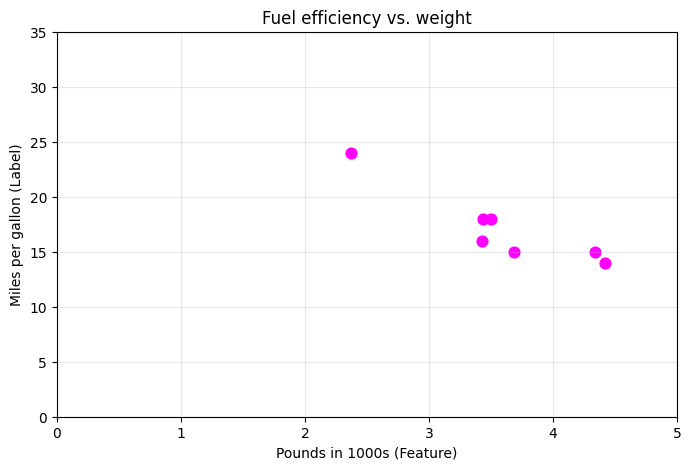

In [257]:
# Visualize the data (same scatter plot as in the slides)
plt.figure(figsize=(8, 5))
plt.scatter(cars["weight"], cars["mpg"], color="magenta", s=60)
plt.xlabel("Pounds in 1000s (Feature)")
plt.ylabel("Miles per gallon (Label)")
plt.title("Fuel efficiency vs. weight")
plt.xlim(0, 5)
plt.ylim(0, 35)
plt.grid(True, alpha=0.3)
plt.show()

In [258]:
x1, y1 = 4.0, 15.6
x2, y2 = 0.0, 34.0
# Slope (weight) using the slope formula
w1 = (y2 - y1) / (x2 - x1)

# Bias is the y-intercept (y value when x = 0)
b = y2

import builtins
builtins.print(f"Weight (w1) = {w1:.2f}, Bias (b) = {b:.2f}")
builtins.print(f"\nModel: y = {b} + ({w1}) * x1")

Weight (w1) = -4.60, Bias (b) = 34.00

Model: y = 34.0 + (-4.6) * x1


In [259]:
# model
def predict_linear(x, bias, weight):
    return bias + weight * x

In [260]:
# predictions
cars["predicted_mpg"] = predict_linear(cars["weight"], b, w1)
cars

,weight,mpg,predicted_mpg
0,3.500,18,17.900
1,3.690,15,17.026
2,3.440,18,18.176
3,3.430,16,18.222
4,4.340,15,14.036
5,4.420,14,13.668
6,2.370,24,23.098


In [261]:
def l1_loss(y_true, y_pred):
    """Sum of absolute differences."""
    return np.sum(np.abs(y_true - y_pred))

def mae(y_true, y_pred):
    """Mean Absolute Error (average L1 loss)."""
    return np.mean(np.abs(y_true - y_pred))

def l2_loss(y_true, y_pred):
    """Sum of squared differences."""
    return np.sum((y_true - y_pred) ** 2)

def mse(y_true, y_pred):
    """Mean Squared Error (average L2 loss)."""
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    """Root Mean Squared Error - square root of MSE."""
    return np.sqrt(mse(y_true, y_pred))

In [262]:
y_true = cars["mpg"].values
y_pred = cars["predicted_mpg"].values

import builtins
builtins.print(f"L1 loss = {l1_loss(y_true, y_pred):.3f}")
builtins.print(f"MAE     = {mae(y_true, y_pred):.3f}")
builtins.print(f"L2 loss = {l2_loss(y_true, y_pred):.3f}")
builtins.print(f"MSE     = {mse(y_true, y_pred):.3f}")
builtins.print(f"RMSE    = {rmse(y_true, y_pred):.3f}")

L1 loss = 6.722
MAE     = 0.960
L2 loss = 10.936
MSE     = 1.562
RMSE    = 1.250


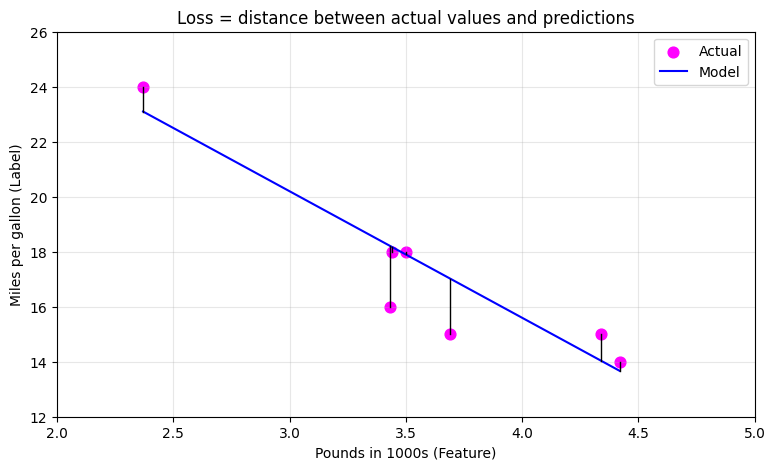

In [263]:
# Visualize the loss as arrows from each data point to the model's prediction
# (this is exactly the "loss lines" figure from the slides)
x_line = np.linspace(cars["weight"].min(), cars["weight"].max(), 100)
y_line = predict_linear(x_line, b, w1)

plt.figure(figsize=(9, 5))
plt.scatter(cars["weight"], cars["mpg"], color="magenta", s=60, label="Actual")
plt.plot(x_line, y_line, color="blue", label="Model")

for _, row in cars.iterrows():
    plt.plot(
        [row["weight"], row["weight"]],
        [row["mpg"], row["predicted_mpg"]],
        color="black", linewidth=1,
    )

plt.xlabel("Pounds in 1000s (Feature)")
plt.ylabel("Miles per gallon (Label)")
plt.title("Loss = distance between actual values and predictions")
plt.xlim(2, 5)
plt.ylim(12, 26)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [264]:
# Show absolute error vs squared error for each data point
comparison = cars[["weight", "mpg", "predicted_mpg"]].copy()
comparison["error"] = comparison["mpg"] - comparison["predicted_mpg"]
comparison["abs_error (L1)"] = np.abs(comparison["error"])
comparison["squared_error (L2)"] = comparison["error"] ** 2

comparison

,weight,mpg,predicted_mpg,error,abs_error (L1),squared_error (L2)
0,3.500,18,17.900,0.100,0.100,0.010
1,3.690,15,17.026,-2.026,2.026,4.105
2,3.440,18,18.176,-0.176,0.176,0.031
3,3.430,16,18.222,-2.222,2.222,4.937
4,4.340,15,14.036,0.964,0.964,0.929
5,4.420,14,13.668,0.332,0.332,0.110
6,2.370,24,23.098,0.902,0.902,0.814
